# 05 - Protocol v2: one properly specified attempt

`04` ran a clean three-way split and still produced a bad answer. It selected a
10-minute horizon on a validation lift of **118x**, which collapsed to **14x** on
test, with an operating point of 0.7 % precision catching 1 failing job out of 127.

The protocol was sound; the **criterion** was wrong, and that was a design error
rather than a property of the data:

* **Lift is `AP / base_rate`.** Shortening the horizon shrinks the denominator, so
  lift rises mechanically as the target gets rarer - even while the model gets
  operationally worse. Selecting on lift guarantees preferring the degenerate end
  of the sweep.
* **The winning cell had 152 validation positives.** Average precision on 152
  positives is extremely unstable, and taking a maximum over 28 such cells is a
  textbook winner's curse.

## What changes, declared in advance

**Change 1 - a minimum sample guard.** A horizon is only eligible if it produces at
least **500 validation positives**. This removes the 10- and 12-minute cells, whose
estimates cannot support a selection.

**Change 2 - a criterion that is comparable across horizons.** Selection is on
**validation job-level average precision**. A job's label - did it end in a failure
state - does not depend on the horizon, so job-level AP measures the same quantity at
every rung of the sweep. Window-level AP and lift do not: they are computed against a
base rate that the horizon itself changes. Job-level AP is also the number that
matches the decision anyone would actually make.

Everything else is unchanged: 64 % fit / 16 % validation / 20 % test by job end date,
selection on validation only, one refit on fit+validation, one evaluation on test.

## This is the last selection pass

Three passes have now been spent choosing conditions that make a number look good.
Each one costs credibility even when executed cleanly. The result of this notebook is
the answer, whichever way it lands - if it does not produce a usable operating point,
the conclusion is that this dataset supports a job-level warning and not a real-time
alarm, and that is what gets written down.

## Pre-registration

**V1.** Validation will select a horizon **longer** than the 10 minutes chosen by the
broken criterion, because job-level AP does not reward rarity.

**V2.** The validation-to-test shrinkage will be far smaller than `04`'s 8x, because
job-level AP on ~2,000 validation jobs is a far more stable estimate than window lift
on 152 positives.

**V3.** The selected model will still be a TIMEOUT detector rather than a hardware
failure detector.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

WINDOW, SNAP_S = 40, 30.0
FLOOR_S  = (WINDOW // 2 - 1) * SNAP_S
HORIZONS = [0.25, 1/3, 0.5, 1.0, 2.0, 4.0]      # 15, 20, 30 min, 1, 2, 4 h
MIN_VAL_POS = 500                                # change 1
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
HARDWARE = ("FAILED", "OUT_OF_MEMORY", "NODE_FAIL")
VAL_FRAC, N_BOOT = 0.20, 300

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print(f"eligibility guard: a horizon needs >= {MIN_VAL_POS} validation positives")

eligibility guard: a horizon needs >= 500 validation positives


## Step 1 - Features and the same three-way split as `04`

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "start_date", "numcores", "end_date"])
w = w.merge(jobs, on="slurm_id", how="left")

TELEMETRY = [c for c in w.columns if "__" in c]
el = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = el / 3600.0
w["sec_into_hour"]       = el % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (el % 3600.0)
w["elapsed_hours_floor"] = np.floor(el / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
w["hour_of_day"]         = w.t_end.dt.hour
w["dow"]                 = w.t_end.dt.dayofweek

CLOCK = ["hour_of_day", "dow"]
C9 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"] + CLOCK
C7 = [c for c in C9 if c not in CLOCK]
SETS = {"T   telemetry": TELEMETRY, "C9  context+clock": C9,
        "C7  context": C7, "T+C7 both": TELEMETRY + C7}

tr_jobs = (w.loc[w.split == "train", ["slurm_id", "end_date"]]
             .drop_duplicates().sort_values(["end_date", "slurm_id"]))
val_ids = set(tr_jobs.slurm_id.iloc[int(len(tr_jobs) * (1 - VAL_FRAC)):])
w["fold"] = np.where(w.split == "test", "test",
             np.where(w.slurm_id.isin(val_ids), "val", "fit"))
M = {f: (w.fold == f).to_numpy() for f in ["fit", "val", "test"]}

is_fail = w.state.astype(str).isin(FAILURE_STATES).to_numpy()
ttf = w.ttf_end.to_numpy()
def relabel(H):
    return (is_fail & (ttf >= 0) & (ttf <= H * 3600 - FLOOR_S)).astype(np.int8)

def job_ap(df_mask, score):
    """AP over JOBS: one score per job (its max window score); positive = job failed."""
    sub = w[df_mask]
    d = pd.DataFrame({"slurm_id": sub.slurm_id.to_numpy(),
                      "state": sub.state.astype(str).to_numpy(), "score": score})
    g = d.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first"))
    yj = g.state.isin(FAILURE_STATES).astype(int).to_numpy()
    return average_precision_score(yj, g.score.to_numpy()), yj, g

print(w.groupby("fold").agg(windows=("y", "size"), jobs=("slurm_id", "nunique")).to_string())

      windows  jobs
fold               
fit    668948  8212
test   142309  2694
val    246560  2053


## Step 2 - Selection on validation job-level AP

The test set is not touched in this cell.

In [3]:
rows = []
for H in HORIZONS:
    yH = relabel(H)
    npos_val = int(yH[M["val"]].sum())
    if npos_val < MIN_VAL_POS:
        print(f"H={60*H:6.1f} min  val positives {npos_val} < {MIN_VAL_POS} - INELIGIBLE")
        continue
    for name, cols in SETS.items():
        m  = lgb.LGBMClassifier(**PARAMS).fit(w.loc[M["fit"], cols], yH[M["fit"]])
        sc = m.predict_proba(w.loc[M["val"], cols])[:, 1]
        jap, yjv, _ = job_ap(M["val"], sc)
        wap = average_precision_score(yH[M["val"]], sc)
        rows.append(dict(horizon_min=60 * H, horizon_h=H, features=name,
                         val_pos=npos_val, val_job_ap=jap, val_job_lift=jap / yjv.mean(),
                         val_win_ap=wap, val_win_lift=wap / yH[M["val"]].mean()))
    print(f"H={60*H:6.1f} min  val positives {npos_val:>6,}  eligible   [{time.time()-t0:.0f}s]")

V = pd.DataFrame(rows)
V.to_csv(DATA / "selection_v2.csv", index=False)
print()
print("VALIDATION job-level AP  (the selection criterion)")
print(V.pivot(index="horizon_min", columns="features", values="val_job_ap").round(4).to_string())
print()
print("VALIDATION window-level lift  (the criterion that failed in 04, for contrast)")
print(V.pivot(index="horizon_min", columns="features", values="val_win_lift").round(2).to_string())

H=  15.0 min  val positives    524  eligible   [43s]


H=  20.0 min  val positives    880  eligible   [81s]


H=  30.0 min  val positives  1,552  eligible   [121s]


H=  60.0 min  val positives  3,355  eligible   [164s]


H= 120.0 min  val positives  6,561  eligible   [204s]


H= 240.0 min  val positives 11,613  eligible   [244s]

VALIDATION job-level AP  (the selection criterion)
features     C7  context  C9  context+clock  T   telemetry  T+C7 both
horizon_min                                                          
15.0              0.5499             0.4669         0.2907     0.4981
20.0              0.5583             0.4757         0.3370     0.5257
30.0              0.5760             0.5283         0.3351     0.5347
60.0              0.5574             0.5320         0.3909     0.5662
120.0             0.4936             0.4451         0.3976     0.5643
240.0             0.4761             0.4293         0.4072     0.5682

VALIDATION window-level lift  (the criterion that failed in 04, for contrast)
features     C7  context  C9  context+clock  T   telemetry  T+C7 both
horizon_min                                                          
15.0              109.04              31.64           1.84      82.71
20.0               73.10              52.77  

In [4]:
best = V.loc[V.val_job_ap.idxmax()]
BEST_H, BEST_SET = float(best.horizon_h), str(best.features)
facts["selected_horizon_min"] = float(best.horizon_min)
facts["selected_features"] = BEST_SET
facts["selected_val_job_ap"] = float(best.val_job_ap)

print(f"SELECTED -> horizon {best.horizon_min:.0f} min, features {BEST_SET}, "
      f"validation job AP {best.val_job_ap:.4f}")
print()
print(f"V1  selection is longer than 04's 10 min : "
      f"{'CONFIRMED' if best.horizon_min > 10 else 'REJECTED'}")

SELECTED -> horizon 30 min, features C7  context, validation job AP 0.5760

V1  selection is longer than 04's 10 min : CONFIRMED


## Step 3 - One refit, one evaluation on test

In [5]:
yB = relabel(BEST_H); cols = SETS[BEST_SET]
trm = M["fit"] | M["val"]
m_best = lgb.LGBMClassifier(**PARAMS).fit(w.loc[trm, cols], yB[trm])
sc_test = m_best.predict_proba(w.loc[M["test"], cols])[:, 1]
te, yte = w[M["test"]], yB[M["test"]]

def ap_ci(y, score, groups, n_boot=N_BOOT, seed=1):
    rng = np.random.default_rng(seed)
    u, inv = np.unique(groups, return_inverse=True)
    o = np.argsort(inv, kind="stable")
    b = np.r_[0, np.cumsum(np.bincount(inv, minlength=len(u)))]
    by = [o[b[i]:b[i+1]] for i in range(len(u))]
    aps = []
    for _ in range(n_boot):
        r = np.concatenate([by[k] for k in rng.integers(0, len(u), len(u))])
        if y[r].sum():
            aps.append(average_precision_score(y[r], score[r]))
    return np.percentile(aps, [2.5, 97.5])

jap_t, yj_t, gj = job_ap(M["test"], sc_test)
jlo, jhi = ap_ci(yj_t, gj.score.to_numpy(), gj.index.to_numpy())
wap_t = average_precision_score(yte, sc_test)
wlo, whi = ap_ci(yte, sc_test, te.slurm_id.to_numpy())

shrink = best.val_job_ap / jap_t
facts.update(test_job_ap=float(jap_t), test_job_ap_ci=[float(jlo), float(jhi)],
             test_job_base=float(yj_t.mean()), test_job_lift=float(jap_t / yj_t.mean()),
             test_win_ap=float(wap_t), test_win_ap_ci=[float(wlo), float(whi)],
             test_win_base=float(yte.mean()), test_win_lift=float(wap_t / yte.mean()),
             val_to_test_shrinkage=float(shrink))

print(f"selected: {60*BEST_H:.0f} min horizon, {BEST_SET} ({len(cols)} columns)")
print()
print(f"JOB LEVEL    AP {jap_t:.4f}  [{jlo:.4f}, {jhi:.4f}]   "
      f"base {100*yj_t.mean():.1f} %   lift {jap_t/yj_t.mean():.2f}x")
print(f"WINDOW LEVEL AP {wap_t:.4f}  [{wlo:.4f}, {whi:.4f}]   "
      f"base {100*yte.mean():.3f} %   lift {wap_t/yte.mean():.2f}x")
print()
print(f"V2  shrinkage validation -> test : {shrink:.2f}x  "
      f"(04's was 8.3x)  -> {'CONFIRMED' if shrink < 3 else 'REJECTED'}")

selected: 30 min horizon, C7  context (7 columns)

JOB LEVEL    AP 0.5017  [0.4570, 0.5461]   base 14.0 %   lift 3.58x
WINDOW LEVEL AP 0.1494  [0.1114, 0.1906]   base 1.053 %   lift 14.19x

V2  shrinkage validation -> test : 1.15x  (04's was 8.3x)  -> CONFIRMED


### Operating points, in jobs

At job level the alert budget is a number of **jobs flagged**, which is what an
operator would actually configure.

In [6]:
gs = gj.assign(y=yj_t).sort_values("score", ascending=False)
n_fail = int(yj_t.sum())
ops = []
for k in [10, 25, 50, 100, 200, 400]:
    top = gs.head(k)
    ops.append(dict(jobs_flagged=k, precision=top.y.mean(),
                    recall=top.y.sum() / n_fail, true_alerts=int(top.y.sum()),
                    lift=top.y.mean() / yj_t.mean()))
O = pd.DataFrame(ops)
O.to_csv(DATA / "operating_points_v2.csv", index=False)
print(f"{len(gs):,} scorable test jobs, {n_fail:,} failing ({100*yj_t.mean():.1f} %)")
print(O.assign(precision=lambda d: (100*d.precision).round(1),
               recall=lambda d: (100*d.recall).round(1),
               lift=lambda d: d.lift.round(2)).to_string(index=False))
facts["job_precision_at_50"] = float(O[O.jobs_flagged == 50].precision.iloc[0])
facts["job_recall_at_50"] = float(O[O.jobs_flagged == 50].recall.iloc[0])

2,694 scorable test jobs, 378 failing (14.0 %)
 jobs_flagged  precision  recall  true_alerts  lift
           10      100.0     2.6           10  7.13
           25      100.0     6.6           25  7.13
           50       96.0    12.7           48  6.84
          100       72.0    19.0           72  5.13
          200       60.5    32.0          121  4.31
          400       42.8    45.2          171  3.05


## Step 4 - Which failure modes, and does the clock finding hold?

In [7]:
st = te.state.astype(str).to_numpy()
mr = []
for mode, states in [("all failures", None), ("TIMEOUT", ("TIMEOUT",)),
                     ("hardware only", HARDWARE), ("FAILED", ("FAILED",)),
                     ("NODE_FAIL", ("NODE_FAIL",)), ("OUT_OF_MEMORY", ("OUT_OF_MEMORY",))]:
    keep = np.ones(len(yte), bool) if states is None else ((yte == 0) | np.isin(st, states))
    yk, sk = yte[keep], sc_test[keep]
    if yk.sum() == 0:
        mr.append(dict(mode=mode, positives=0, ap=np.nan, lift=np.nan)); continue
    a = average_precision_score(yk, sk)
    mr.append(dict(mode=mode, positives=int(yk.sum()), ap=a, lift=a / yk.mean()))
MD = pd.DataFrame(mr); MD.to_csv(DATA / "modes_v2.csv", index=False)
print(MD.round(4).to_string(index=False))

t_l = MD[MD["mode"] == "TIMEOUT"].lift.iloc[0]; h_l = MD[MD["mode"] == "hardware only"].lift.iloc[0]
facts["timeout_lift"] = float(t_l); facts["hardware_lift"] = float(h_l)
print()
print(f"V3  still a TIMEOUT detector : "
      f"{'CONFIRMED' if t_l > 1.5 * h_l else 'REJECTED'} "
      f"(TIMEOUT {t_l:.2f}x vs hardware {h_l:.2f}x)")

c7 = V[V.features == "C7  context"].set_index("horizon_min").val_job_ap
c9 = V[V.features == "C9  context+clock"].set_index("horizon_min").val_job_ap
facts["c7_beats_c9_job_level"] = f"{int((c7>c9).sum())}/{len(c7)}"
print(f"    clock columns still harmful at job level: C7 beats C9 at "
      f"{int((c7>c9).sum())} of {len(c7)} horizons")

         mode  positives     ap    lift
 all failures       1498 0.1494 14.1914
      TIMEOUT        968 0.2036 29.8235
hardware only        530 0.0077  2.0590
       FAILED        405 0.0059  2.0734
    NODE_FAIL         72 0.0012  2.3038
OUT_OF_MEMORY         53 0.0012  3.2877

V3  still a TIMEOUT detector : CONFIRMED (TIMEOUT 29.82x vs hardware 2.06x)
    clock columns still harmful at job level: C7 beats C9 at 6 of 6 horizons


## Step 5 - Figure and the honest comparison

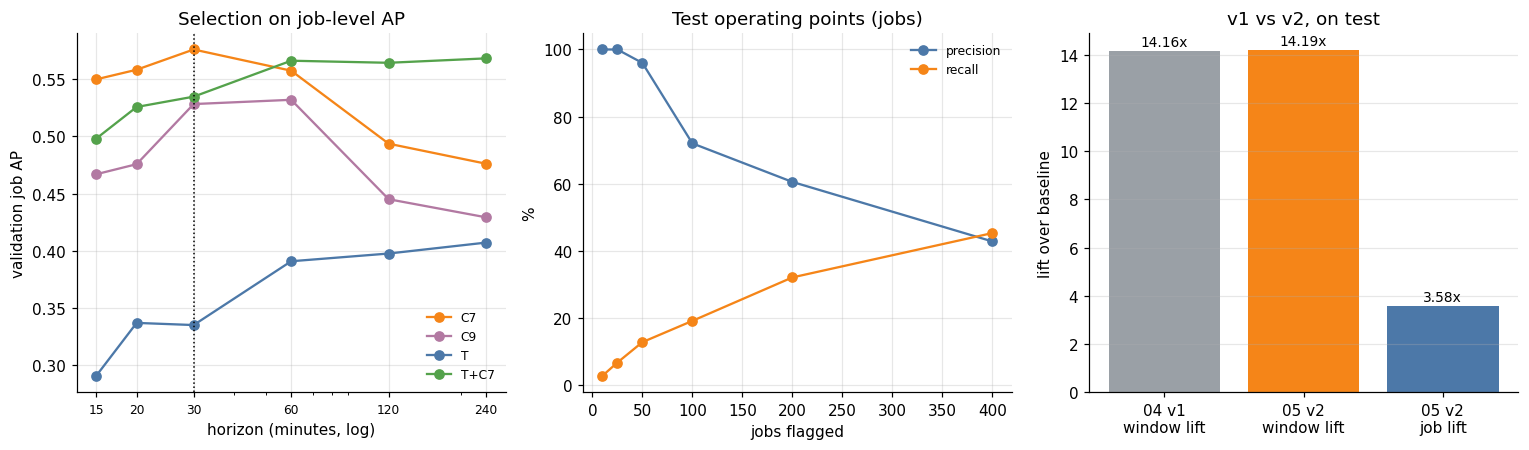

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

piv = V.pivot(index="horizon_min", columns="features", values="val_job_ap")
for col, c in zip(piv.columns, ["#f58518", "#b279a2", "#4c78a8", "#54a24b"]):
    ax[0].plot(piv.index, piv[col], "o-", color=c, label=col.split()[0])
ax[0].axvline(best.horizon_min, color="k", ls=":", lw=1)
ax[0].set(xscale="log", xlabel="horizon (minutes, log)", ylabel="validation job AP",
          title="Selection on job-level AP")
ax[0].set_xticks(piv.index, [f"{m:.0f}" for m in piv.index], fontsize=8)
ax[0].legend(frameon=False, fontsize=8)

ax[1].plot(O.jobs_flagged, 100 * O.precision, "o-", color="#4c78a8", label="precision")
ax[1].plot(O.jobs_flagged, 100 * O.recall, "o-", color="#f58518", label="recall")
ax[1].set(xlabel="jobs flagged", ylabel="%", title="Test operating points (jobs)")
ax[1].legend(frameon=False, fontsize=8)

labels = ["04 v1\nwindow lift", "05 v2\nwindow lift", "05 v2\njob lift"]
vals = [14.16, wap_t / yte.mean(), jap_t / yj_t.mean()]
ax[2].bar(labels, vals, color=["#9aa0a6", "#f58518", "#4c78a8"])
for i, v in enumerate(vals):
    ax[2].text(i, v + .2, f"{v:.2f}x", ha="center", fontsize=9)
ax[2].set(ylabel="lift over baseline", title="v1 vs v2, on test")
ax[2].grid(axis="x", visible=False)

plt.tight_layout(); save(fig, "05_protocol_v2.png"); plt.show()

In [9]:
json.dump(facts, open(DATA / "facts_v2.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:26s} {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

selected_horizon_min       30.0
selected_features          C7  context
selected_val_job_ap        0.5759696728702117
test_job_ap                0.5017353034661887
test_job_ap_ci             [0.4569846708311141, 0.5460781411690829]
test_job_base              0.1403118040089087
test_job_lift              3.5758595437510907
test_win_ap                0.1493842227668362
test_win_ap_ci             [0.11138619369352022, 0.19056450381023288]
test_win_base              0.010526389757499525
test_win_lift              14.191401440404334
val_to_test_shrinkage      1.1479552443114571
job_precision_at_50        0.96
job_recall_at_50           0.12698412698412698
timeout_lift               29.823514382155928
hardware_lift              2.0589769411271956
c7_beats_c9_job_level      6/6

[257s total]


### What gets written down

Both protocols are reported. `04` selected on window-level lift and produced a
14.16x detector whose top 142 alerts contained one true positive; `05` selected on
job-level average precision under a minimum-sample guard. The difference between
them is a result in its own right, and a transferable one: **on a rare-event task,
selecting a model on lift will reliably choose the rarest and least useful target,
because lift divides by the very quantity the choice is shrinking.**

The coverage caveat is unchanged and travels with every job-level number here: only
jobs that produced at least one complete 20-minute window can be scored at all, and
`eda/` measured that two thirds of failing jobs never do. A job-level average
precision describes how well observable failures are ranked. It is not the fraction
of failures that would be caught in production.